## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [ ]:
! git clone https://github.com/anishjagota/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 126 (delta 48), reused 20 (delta 20), pack-reused 66 (from 2)
Receiving objects: 100% (126/126), 15.47 MiB | 7.31 MiB/s, done.
Resolving deltas: 100% (53/53), done.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('/content/undergrad_ml_assignments/data/golub.csv')
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [ ]:
# Question 1
df['y'] = df['cancer'].str.lower().replace({
    'allb': 0,
    'allt': 0,
    'aml': 1
})
df[['cancer', 'y']].head()

/tmp/ipykernel_180/1236968034.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['y'] = df['cancer'].str.lower().replace({


,cancer,y
0,allB,0
1,allB,0
2,allB,0
3,allB,0
4,allB,0


Mean squared error: 1.2522824482837894e-30


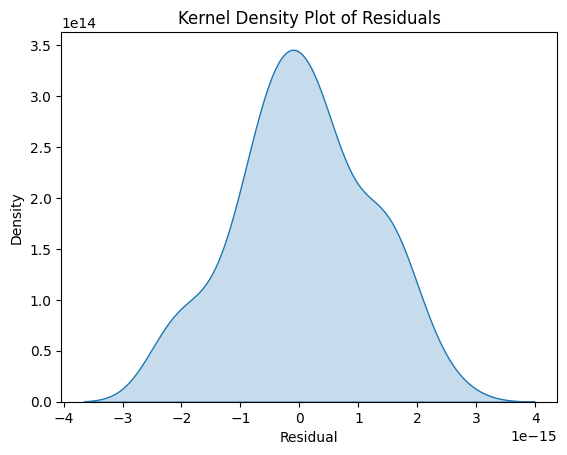

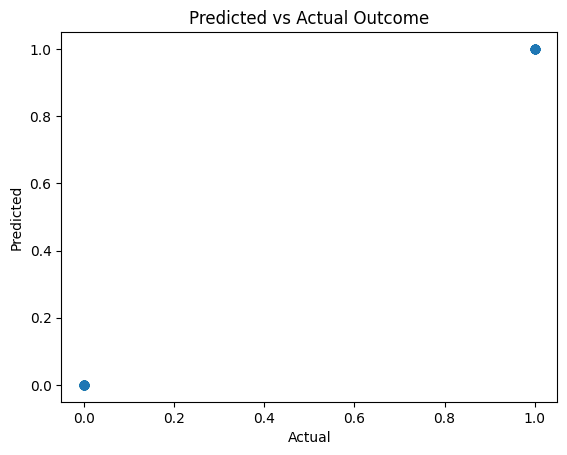

In [ ]:
#Question 2

X = df.drop(columns=['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'y'])
y = df['y']
model = LinearRegression()
model.fit(X, y)
y_hat = model.predict(X)
mse = mean_squared_error(y, y_hat)
print("Mean squared error:", mse)

residuals = y - y_hat
sns.kdeplot(residuals, fill=True)
plt.xlabel("Residual")
plt.title("Kernel Density Plot of Residuals")
plt.show()
plt.scatter(y, y_hat, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual Outcome")
plt.show()

In [ ]:
#Question 3
model = LinearRegression()
kf = KFold(n_splits=10, shuffle=True, random_state=100)
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring='neg_mean_squared_error'
)
cv_mse = -cv_scores
print("Fold MSEs:", cv_mse)
print("Cross-validated MSE:", cv_mse.mean())

Fold MSEs: [0.02265367 0.04875751 0.06347474 0.06304086 0.09383082 0.08300696
 0.0207161  0.01969831 0.02087605 0.02271393]
Cross-validated MSE: 0.045876895088525556


Using 10-fold cross-validation, the linear model’s mean squared error is 0.0459. This is much higher than the training MSE from Question 2, which was essentially 0. This shows the model is overfitting. The linear regression has very low bias on the training set but very high variance out of sample. It fits the training data almost perfectly, but its performance gets worse on unseen folds.

Selected genes: ['AF000560_at', 'AF002020_at', 'AF006087_at', 'D26579_at', 'D29956_at', 'D42043_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04101_at', 'J04164_at', 'L12723_at', 'L13848_at', 'L20941_at', 'M12759_at', 'M17754_at', 'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at', 'M27891_at', 'M28713_at', 'M31994_at', 'M34344_at', 'M63138_at', 'M84526_at', 'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at', 'U14588_at', 'U30828_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at', 'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at', 'U82759_at', 'U88666_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at', 'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X66867_cds1_at', 'X69111_at', 'X81479_at', 'X83378_at', 'X95735_at', 'X96698_at', 'Y00636_at', 'Y07604_at', 'Y07755_at', 'Y10207_at', 'Y12670_at', 'M96843_at', 'X58072_at', 'AC002477_s_at', 'L15326_s_at', 'X57351_at', 'K02777_s_at', 'U37055_rna1_s_at', 'U59632_s_at', 'X07438_s_at', 'M12959_s_at', 'M13690_s_at', 'M26

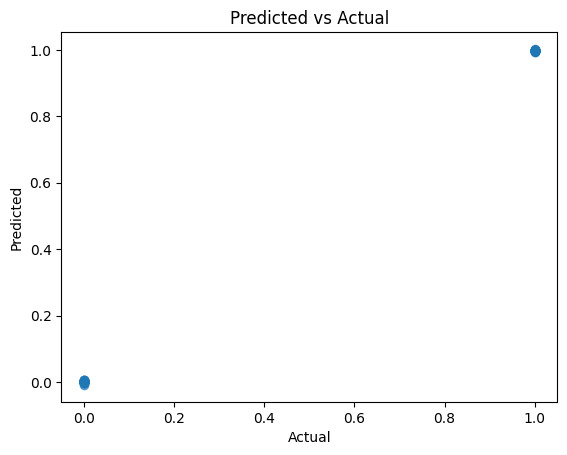

In [ ]:
#Question 4:
X = df.drop(columns=['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'y'])
y = df['y']

X_scaled = StandardScaler().fit_transform(X)
lasso = LassoCV(cv=10, random_state=100, max_iter=10000)
lasso.fit(X_scaled, y)

selected_genes = X.columns[lasso.coef_ != 0]
print("Selected genes:", selected_genes.tolist())
print("Number selected:", len(selected_genes))
print("Number discarded:", X.shape[1] - len(selected_genes))
y_hat = lasso.predict(X_scaled)
plt.scatter(y, y_hat, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

The cross-validated LASSO selected 81 genes with nonzero coefficients and discarded 7,048 genes by shrinking their coefficients to zero. The selected genes are the predictors with nonzero LASSO coefficients. The predicted-versus-actual scatterplot shows that the LASSO model separates the two classes well while using a much smaller subset of genes than the full linear model.

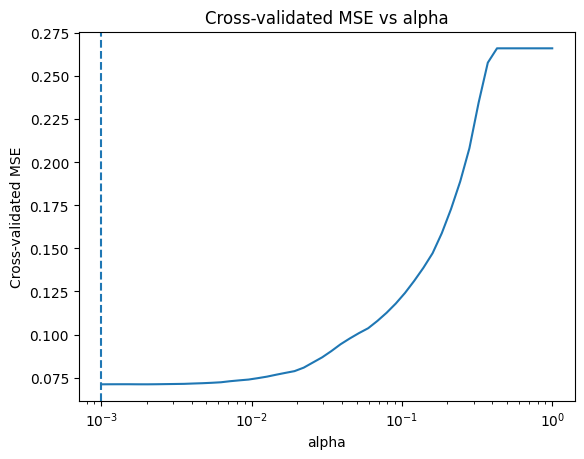

Optimal alpha: 0.001


In [ ]:
#Question 5:
cv_mse = lasso.mse_path_.mean(axis=1)
alpha_star = lasso.alpha_

plt.plot(lasso.alphas_, cv_mse)
plt.axvline(alpha_star, linestyle='--')
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('Cross-validated MSE vs alpha')
plt.show()

print("Optimal alpha:", alpha_star)

The cross-validated MSE is lowest at alpha = 0.001, so this is the optimal penalty hyperparameter. As alpha increases, the cross-validated MSE rises, which suggests the LASSO begins to underfit because the penalty becomes too strong and shrinks too many coefficients toward zero. In the range of alpha values tested, I think there is no clear evidence of overfitting, since the minimum occurs at the smallest alpha considered.

**Question 6:**

Linear regression performs perfectly on the training set because there are far more predictors than observations here: about 7,129 genes and only 72 patients. That gives the model enough flexibility to fit the training data almost exactly, so the training error is essentially zero. LASSO model performs better overall because it adds a penalty that shrinks many coefficients to zero and keeps only the most useful genes. This reduces overfitting and lowers the model’s variance, so it generalizes better to new data.

**Question 7:**

Precision health often has many predictors (like thousands of genes) but few patients. Regularization helps by shrinking or removing less useful variables, which reduces overfitting and improves prediction on new patients. It also makes the model simpler and easier to interpret by focusing on the most informative predictors.

**Question 8:**

A model like LASSO can still make wrong or unstable selections, especially with small samples and noisy data. Important genes may be left out, or selected genes may not be truly causal. If decisions or treatments are based too heavily on the model, patients could receive the wrong intervention. There is also a risk that the model may not generalize well to other populations, which can lead to biased or unreliable clinical decisions.